In [9]:
from typing import TypedDict, Dict  # TypeDict is used to define a dictionary with a fixed structure.
from langgraph.graph import StateGraph, START, END
import math

In [10]:
class AgentState(TypedDict):
    values : list[str]
    name : str
    operation : str
    result : str

def calculating_node(state: AgentState)-> AgentState:
    """Simple node that handle multiple different input."""
    if state['operation']=='+':
        state['result'] = f"Hi {state['name']}, your sum is {sum(state['values'])}"
    elif state['operation'] == '*':
        state['result'] = f"Hi {state['name']}, your product is {math.prod(state['values'])}"
    
    return state

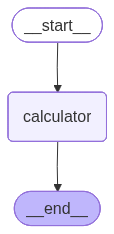

In [11]:
graph = StateGraph(state_schema=AgentState)

graph.add_node("calculator", calculating_node)

graph.set_entry_point('calculator')
graph.set_finish_point('calculator')

agent = graph.compile()
agent

In [12]:
result = agent.invoke({'name': 'Rimon', 'values':[5,10,15], 'operation':'*'})
result['result']

'Hi Rimon, your product is 750'